# Lezione 7B — Context Engineering e Agno

**Corso**: Programmazione di Applicazioni Intelligenti  
**Argomento**: Context Engineering (teoria e pratica), introduzione al framework Agno  
**Durata**: ~1.5 ore (lezione pratica: teoria + live coding)  
**Prerequisiti**: Notebook 7A (agenti, ReAct, implementazione from scratch)

---

**Obiettivi di questa lezione**:
- Comprendere il **Context Engineering**: le 6 componenti del contesto e le 4 strategie di gestione
- Implementare in pratica la strategia **Compress** (riassunto cronologia); inquadrare le altre strategie (Write, Select, Isolate) che verranno approfondite nelle lezioni successive
- Passare dall'implementazione artigianale al framework **Agno**: stessi risultati, meno codice
- Costruire un agente Agno con **tool custom**, **web search reale** e **conversazioni multi-turno**

> In questo notebook usiamo:
> - `mistral-small-latest` via **Mistral** per la parte artigianale (come nel notebook 7A)
> - `mistral-small-latest` via **Mistral** per le demo con Agno — ha un eccellente supporto per il tool calling e un free tier molto generoso (~1 miliardo di token/mese)


In [1]:
# === Setup: dipendenze e client Mistral (per la parte artigianale) ===

!pip install -q openai

from openai import OpenAI
from google.colab import userdata
import json

client = OpenAI(
    base_url="https://api.mistral.ai/v1",
    api_key=userdata.get("MISTRAL_API_KEY"),
)

MODEL = "mistral-small-latest"
print(f"Client configurato — modello: {MODEL}")


Client configurato — modello: mistral-small-latest


---
## 2.1 — Context Engineering: l'arte di gestire il contesto

Negli ultimi mesi si è affermato un termine che va oltre il "prompt engineering":

> **Context Engineering** — l'arte di fornire tutto il contesto necessario perché l'LLM possa risolvere il task.
>
> — Philipp Schmid, Tobi Lutke (CEO Shopify), Andrej Karpathy

La differenza è significativa:
- **Prompt engineering** = scrivere un buon prompt (una stringa di testo)
- **Context engineering** = **orchestrare tutte le fonti di contesto** — system prompt, tool descriptions, memoria, dati recuperati, output intermedi, stato dell'utente

Karpathy ha usato una metafora efficace: il contesto è la **RAM dell'LLM OS** — tutto ciò che il modello può "vedere" quando genera la risposta. E come la RAM, è limitata.


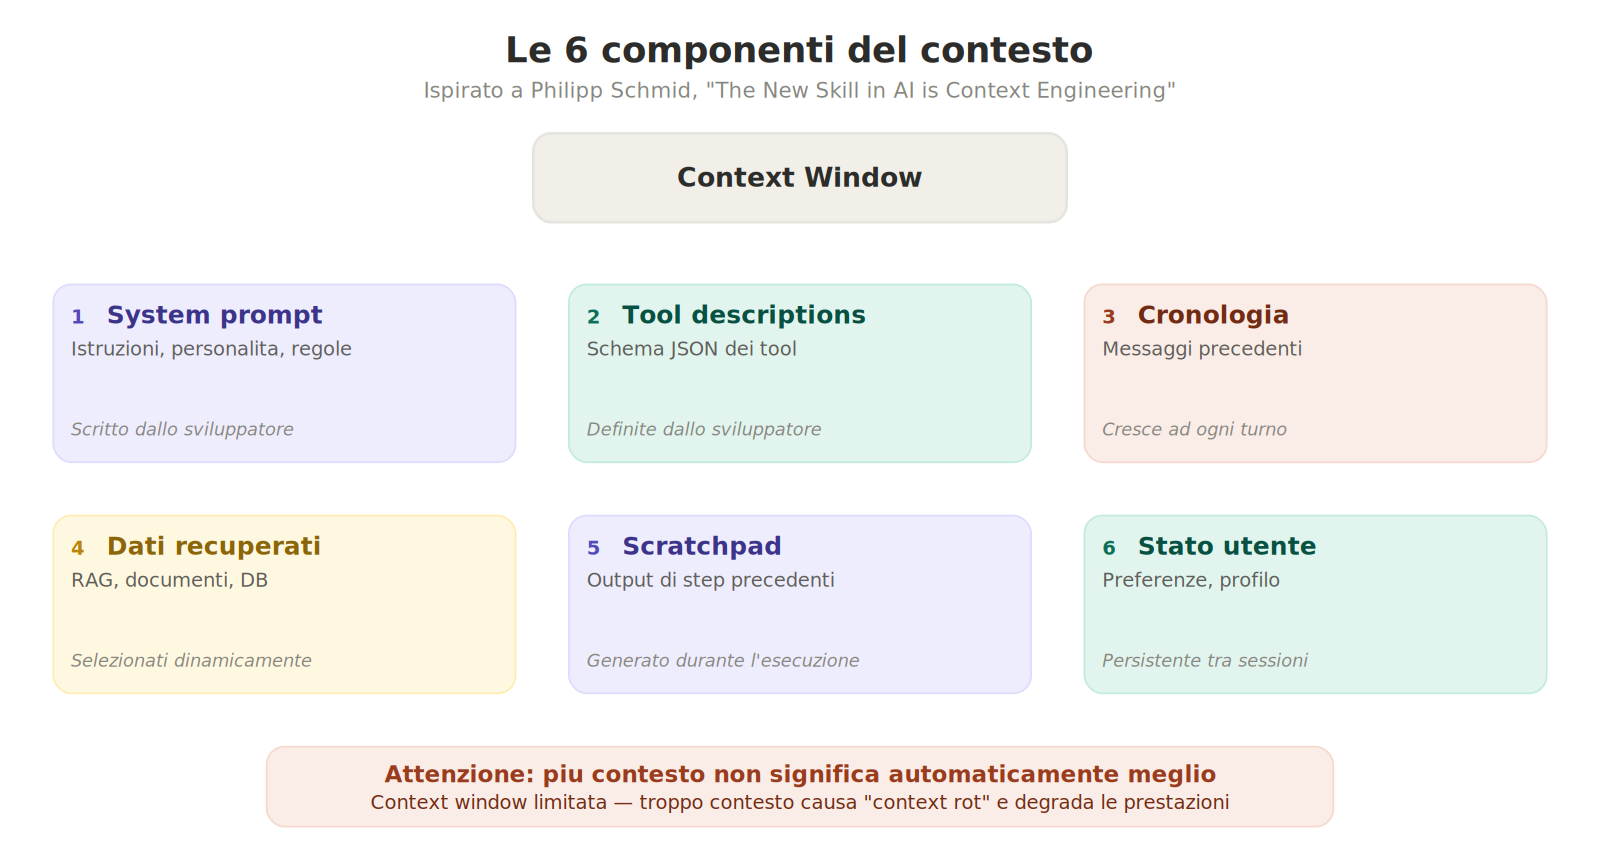

### Le 4 strategie di gestione del contesto

| Strategia | Cosa fa | Esempio |
|---|---|---|
| **Write** | Salvare contesto *fuori* dalla window | Scrivere in un DB, file, scratchpad esterno |
| **Select** | Recuperare solo il contesto *rilevante* | RAG, memory retrieval, search |
| **Compress** | Riassumere/potare il contesto | Summarization della cronologia, trimming |
| **Isolate** | Dividere il contesto tra sub-agenti | Ogni agente vede solo il suo pezzo |

Queste strategie non sono mutualmente esclusive — un sistema reale le usa in combinazione.

> **Nota per il docente**: la tensione fondamentale del context engineering: il modello lavora meglio con più contesto rilevante, ma la window è finita. Ogni strategia è un trade-off.


### Il principio del "prompt shape": prefisso stabile vs parte variabile

In pratica, un agent harness ben progettato separa il contesto in due zone:

- **Prefisso stabile**: system prompt + tool descriptions + workspace summary — cambia raramente, può essere **cachato** (prompt caching di Anthropic/OpenAI riduce costi e latenza fino al 90%)
- **Parte variabile**: transcript recente + richiesta utente + working memory — cambia ad ogni turno

Questo è un principio di context engineering applicato all'efficienza: non ricostruire tutto da zero ad ogni chiamata. Le API moderne supportano questo pattern nativamente con il prompt caching, ma il principio vale anche nella progettazione manuale dei prompt.

> **Nota per il docente**: collegare al costo. Ogni token nel prefisso stabile, se cachato, costa ~10x meno. Con un agente che fa 20 step per task e 2000 token di prefisso, il risparmio è significativo.

### Demo 1 — Strategia Compress: riassumere la cronologia

Quando la cronologia supera una soglia, **riassumiamo i messaggi più vecchi** con una chiamata LLM.

In [ ]:
# === Context Compression ===

def count_tokens_approx(messages: list) -> int:
    """Stima approssimativa dei token (~1 token ogni 3 caratteri per testo italiano)."""
    total_chars = sum(len(m.get("content", "") or "") for m in messages)
    return total_chars // 3

def compress_history(messages: list, max_tokens: int = 2000, keep_recent: int = 4) -> list:
    """Comprime la cronologia se supera max_tokens."""
    if count_tokens_approx(messages) <= max_tokens:
        return messages

    system = messages[0]
    recent = messages[-keep_recent:]
    to_compress = messages[1:-keep_recent]

    if not to_compress:
        return messages

    history_text = "\n".join(f"[{m['role']}]: {m.get('content','')}" for m in to_compress)

    summary_response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "Riassumi questa conversazione in modo conciso, mantenendo i fatti importanti. Rispondi SOLO con il riassunto."},
            {"role": "user", "content": history_text}
        ],
        max_tokens=max_tokens
    )
    summary = summary_response.choices[0].message.content
    return [system, {"role": "system", "content": f"[Riassunto conversazione precedente]: {summary}"}] + recent

print("Funzione compress_history definita!")


Funzione compress_history definita!


In [ ]:
# === Test: conversazione lunga → compressione ===

messages = [
    {"role": "system", "content": "Sei un assistente utile e preciso."},
    {"role": "user", "content": "Ciao, sto organizzando un viaggio in Giappone."},
    {"role": "assistant", "content": "Che bello! Il Giappone e' una destinazione fantastica. Quando vorresti partire e per quanto tempo?"},
    {"role": "user", "content": "Vorrei partire a marzo per 2 settimane. Budget di circa 3000 euro."},
    {"role": "assistant", "content": "Marzo e' perfetto per i ciliegi in fiore! Con 3000 euro per 2 settimane puoi coprire volo, alloggi in ostello/capsule hotel, Japan Rail Pass, e cibo. Ti consiglio Tokyo, Kyoto, Osaka e Hiroshima."},
    {"role": "user", "content": "Mi piacerebbe anche visitare il Monte Fuji. E' possibile a marzo?"},
    {"role": "assistant", "content": "A marzo il Monte Fuji e' ancora coperto di neve e la stagione ufficiale di arrampicata e' da luglio a settembre. Pero' puoi ammirarlo da Hakone o dalla regione dei 5 laghi con vista spettacolare."},
    {"role": "user", "content": "Ok, allora Hakone. E per il Japan Rail Pass, quanto costa?"},
    {"role": "assistant", "content": "Il Japan Rail Pass per 14 giorni costa circa 50.000 yen (circa 310 euro). Ti permette di prendere tutti i treni JR, incluso lo Shinkansen. E' molto conveniente per il tuo itinerario."},
    {"role": "user", "content": "Perfetto. E per gli alloggi, consigli ostelli o capsule hotel?"},
    {"role": "assistant", "content": "Dipende dalle tue preferenze: gli ostelli costano 20-30 euro/notte e offrono socializzazione. I capsule hotel sono un'esperienza unica (30-40 euro/notte) ma meno comodi per soggiorni lunghi. Ti consiglio un mix."},
    {"role": "user", "content": "Ok, allora facciamo un mix. Ricapitolami l'itinerario."},
]

print(f"Messaggi originali: {len(messages)}")
print(f"Token stimati: ~{count_tokens_approx(messages)}")

compressed = compress_history(messages, max_tokens=300, keep_recent=4)

print(f"\nMessaggi dopo compressione: {len(compressed)}")
print(f"Token stimati dopo: ~{count_tokens_approx(compressed)}")
for i, m in enumerate(compressed):
    role = m.get("role", "?")
    content = (m.get("content", "") or "")[:120]
    print(f"  [{i}] {role}: {content}{'...' if len(m.get('content','') or '') > 120 else ''}")


Messaggi originali: 12
Token stimati: ~422

Messaggi dopo compressione: 6
Token stimati dopo: ~265
  [0] system: Sei un assistente utile e preciso.
  [1] system: [Riassunto conversazione precedente]: Viaggio in Giappone a marzo per 2 settimane con budget di 3000 euro. Itinerario co...
  [2] assistant: Il Japan Rail Pass per 14 giorni costa circa 50.000 yen (circa 310 euro). Ti permette di prendere tutti i treni JR, incl...
  [3] user: Perfetto. E per gli alloggi, consigli ostelli o capsule hotel?
  [4] assistant: Dipende dalle tue preferenze: gli ostelli costano 20-30 euro/notte e offrono socializzazione. I capsule hotel sono un'es...
  [5] user: Ok, allora facciamo un mix. Ricapitolami l'itinerario.


### Working memory vs full transcript

La demo di compressione che abbiamo appena visto implementa un pattern più generale, descritto da Raschka (*Components of a Coding Agent*, 2026): un agent serio mantiene **due layer di stato**:

- **Full transcript** — la cronologia completa di ogni turno, salvata su disco (JSON, DB). Non entra mai tutta nel prompt, ma è disponibile per consultazione e ripresa sessione.
- **Working memory** — una versione distillata e compatta dei fatti rilevanti: task corrente, file importanti, decisioni prese. Questa entra nel prompt.

La nostra `compress_history()` è esattamente il meccanismo che produce la working memory dal full transcript. In Agno, `add_history_to_context=True` + `num_history_runs=5` fa qualcosa di simile: seleziona solo le ultime N interazioni (working memory) dal database (full transcript).

### Demo 2 — Strategia Select: recuperare solo il contesto rilevante

La strategia **Compress** riduce la cronologia riassumendola. La strategia **Select** è diversa: **sceglie** quali messaggi includere nel contesto, scartando quelli irrilevanti.

Esempio pratico: un chatbot di supporto tecnico che ha una cronologia lunga. L'utente chiede qualcosa su un argomento specifico — non servono *tutti* i messaggi precedenti, ma solo quelli sullo stesso tema.


In [ ]:
# === Strategia Select: filtrare per rilevanza ===

def select_relevant_messages(messages: list, query: str, keep_recent: int = 2) -> list:
    """
    Seleziona dal contesto solo i messaggi rilevanti alla query corrente.
    Approccio semplice: keyword matching (in produzione si userebbe un embedding).
    Mantiene sempre: system prompt + ultimi keep_recent messaggi.
    """
    if len(messages) <= keep_recent + 1:
        return messages

    system = [messages[0]]  # system prompt sempre incluso
    recent = messages[-keep_recent:]  # ultimi N messaggi sempre inclusi
    middle = messages[1:-keep_recent]  # candidati al filtraggio

    # Keyword matching semplice: tieni i messaggi che contengono parole della query
    query_words = set(query.lower().split())
    # Rimuovi stop words italiane comuni
    stop_words = {"il", "la", "le", "lo", "di", "da", "in", "a", "e", "per", "con", "su",
                  "un", "una", "che", "mi", "come", "cosa", "del", "della", "dei", "sono"}
    query_words -= stop_words

    relevant = []
    for msg in middle:
        content = (msg.get("content", "") or "").lower()
        if any(word in content for word in query_words):
            relevant.append(msg)

    result = system + relevant + recent
    print(f"Select: {len(messages)} messaggi -> {len(result)} (scartati {len(messages) - len(result)})")
    print(f"  Query words: {query_words}")
    print(f"  Messaggi rilevanti trovati: {len(relevant)}")
    return result


# Test: conversazione mista con temi diversi
chat_history = [
    {"role": "system", "content": "Sei un assistente di viaggio."},
    {"role": "user", "content": "Voglio andare a Tokyo in primavera."},
    {"role": "assistant", "content": "Tokyo in primavera e' fantastica per i ciliegi! Budget?"},
    {"role": "user", "content": "Budget 3000 euro, volo incluso."},
    {"role": "assistant", "content": "Con 3000 euro puoi stare 10 giorni. Volo ~600 euro."},
    {"role": "user", "content": "Parlami anche di Kyoto, vorrei visitare i templi."},
    {"role": "assistant", "content": "Kyoto ha oltre 2000 templi. I piu famosi: Kinkaku-ji, Fushimi Inari."},
    {"role": "user", "content": "Che tipo di cibo devo provare?"},
    {"role": "assistant", "content": "Ramen, sushi fresco, takoyaki a Osaka, matcha a Kyoto."},
    {"role": "user", "content": "Ho anche bisogno di un hotel a Roma per un weekend."},
    {"role": "assistant", "content": "Per Roma consiglio zona Trastevere o Centro Storico. 80-120 euro/notte."},
    # La prossima domanda riguarda solo il Giappone
    {"role": "user", "content": "Quanto costa il Japan Rail Pass per Kyoto e Tokyo?"},
]

query = chat_history[-1]["content"]
selected = select_relevant_messages(chat_history, query, keep_recent=2)

print("\nMessaggi selezionati:")
for i, m in enumerate(selected):
    content = (m.get('content', '') or '')[:80]
    print(f"  [{i}] {m['role']}: {content}...")


Select: 12 messaggi -> 6 (scartati 6)
  Query words: {'costa', 'kyoto', 'tokyo?', 'japan', 'pass', 'quanto', 'rail'}
  Messaggi rilevanti trovati: 3

Messaggi selezionati:
  [0] system: Sei un assistente di viaggio....
  [1] user: Parlami anche di Kyoto, vorrei visitare i templi....
  [2] assistant: Kyoto ha oltre 2000 templi. I piu famosi: Kinkaku-ji, Fushimi Inari....
  [3] assistant: Ramen, sushi fresco, takoyaki a Osaka, matcha a Kyoto....
  [4] assistant: Per Roma consiglio zona Trastevere o Centro Storico. 80-120 euro/notte....
  [5] user: Quanto costa il Japan Rail Pass per Kyoto e Tokyo?...


**Cosa osservare**: la domanda riguarda il Japan Rail Pass (Giappone). La strategia Select ha scartato i messaggi su Roma — irrilevanti per la query — e ha mantenuto quelli su Tokyo e Kyoto. In produzione, al posto del keyword matching si usano **embedding + similarità coseno** (RAG), ma il principio è identico: *non tutto il contesto merita di entrare nel prompt*.

> **Nota per il docente**: collegare a `num_history_runs` di Agno, che è una versione semplificata di Select (prende le ultime N interazioni, non le più rilevanti). Un Select "vero" richiede un retrieval system.


### Demo 3 — Strategia Isolate: contesti separati per sub-task

La strategia **Isolate** è la più radicale: invece di comprimere o filtrare un unico contesto, si **divide** il lavoro tra più chiamate LLM, ciascuna con il proprio contesto ridotto.

Esempio: un agente deve analizzare un documento lungo e rispondere a domande specifiche. Anziché passare tutto il documento + tutta la cronologia in un'unica chiamata (rischiando di sforare la context window), si può:
1. Una chiamata per **estrarre i fatti rilevanti** dal documento
2. Una chiamata separata per **rispondere alla domanda** usando solo i fatti estratti

Ogni chiamata vede solo il contesto che le serve.


In [ ]:
# === Strategia Isolate: due chiamate con contesti separati ===

# Simuliamo un "documento lungo" (in realta breve, ma il pattern e' lo stesso)
documento = """
Report trimestrale Q1 2026 — TechCorp Srl

Fatturato: 2.3M euro (+12% YoY). Costi operativi: 1.8M euro.
Dipendenti: 45 (erano 38 a Q1 2025). Nuove assunzioni: 3 sviluppatori, 2 data scientist, 2 sales.
Prodotto principale: piattaforma AI per analisi documenti. 127 clienti attivi.
Churn rate: 4.2% (in calo dal 6.1% di Q4 2025).
Prossimi obiettivi: lancio modulo RAG enterprise, espansione mercato DACH.
Rischi: dipendenza da un singolo cloud provider, 2 posizioni senior scoperte.
"""

domanda_utente = "L'azienda e' in crescita? Quali sono i rischi principali?"

# STEP 1: Estrai fatti rilevanti (contesto = solo il documento)
print("=== STEP 1: Estrazione fatti (contesto isolato: solo documento) ===")
extraction = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "system", "content": "Estrai i fatti chiave dal documento. Rispondi con un elenco di fatti, massimo 5. Solo fatti, nessuna interpretazione."},
        {"role": "user", "content": documento}
    ]
)
fatti = extraction.choices[0].message.content
print(f"Fatti estratti:\n{fatti}")
print(f"Token usati: {extraction.usage.total_tokens}")

# STEP 2: Rispondi alla domanda (contesto = solo i fatti + la domanda)
print(f"\n=== STEP 2: Risposta (contesto isolato: fatti + domanda) ===")
answer = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "system", "content": "Rispondi alla domanda basandoti SOLO sui fatti forniti. Se non hai informazioni sufficienti, dillo."},
        {"role": "user", "content": f"Fatti:\n{fatti}\n\nDomanda: {domanda_utente}"}
    ]
)
print(f"Risposta:\n{answer.choices[0].message.content}")
print(f"Token usati: {answer.usage.total_tokens}")

print(f"\n=== Token totali (2 chiamate isolate): {extraction.usage.total_tokens + answer.usage.total_tokens} ===")
print("→ Ogni chiamata ha visto solo il contesto strettamente necessario.")
print("  Con documenti di 50+ pagine, questo pattern e' essenziale.")


**Il pattern Map-Reduce per i documenti**: la demo qui sopra è un caso semplice (un solo chunk), ma il principio si generalizza. Con un documento di 100 pagine:
- **Map**: si divide in chunk, e per ciascuno si estraggono i fatti (N chiamate isolate, parallelizzabili)
- **Reduce**: si aggregano i fatti e si risponde alla domanda (1 chiamata)

Questo è esattamente il pattern che molti framework RAG usano sotto il cofano. Nella Lezione 10 vedremo come Agno implementa la strategia Isolate con i **Team** e i **Workflow** — sub-agenti con contesti separati che collaborano.

> **Nota per il docente**: il punto pedagogico chiave è che **Isolate non è un hack**, ma un principio architetturale. Lo stesso principio vale per i team di agenti: ogni agente vede solo il suo pezzo del problema. Se il tempo è poco, si può saltare questa demo e menzionare solo il concetto — la demo Compress è più fondamentale.


> **Nota per il docente**: se il tempo è limitato, è possibile saltare una delle due demo Agno finali (web search o multi-turno). La demo multi-turno è la più importante perché mostra la memoria — privilegiare quella se bisogna scegliere.

---
## 2.2 — Da artigianale a framework: introduzione ad Agno

Implementare tutto a mano funziona per capire i concetti, ma **non scala**. Esistono diversi framework: LangChain/LangGraph, CrewAI, **Agno**, Autogen.

**Perché Agno per questo corso?**
- API Pythonic e minimale — poche righe per un agente funzionante
- Tool come semplici funzioni Python (Agno genera lo schema automaticamente)
- Supporto nativo per molti provider: Groq, Mistral, Google Gemini, OpenAI, Anthropic, Ollama

**Perché Mistral per le demo Agno?**
- Free tier molto generoso (~1 miliardo di token/mese, nessuna carta di credito)
- Buon supporto per il tool calling nativo
- Provider europeo (GDPR-compliant) — rilevante per un corso italiano
- API key gratuita da [console.mistral.ai](https://console.mistral.ai)


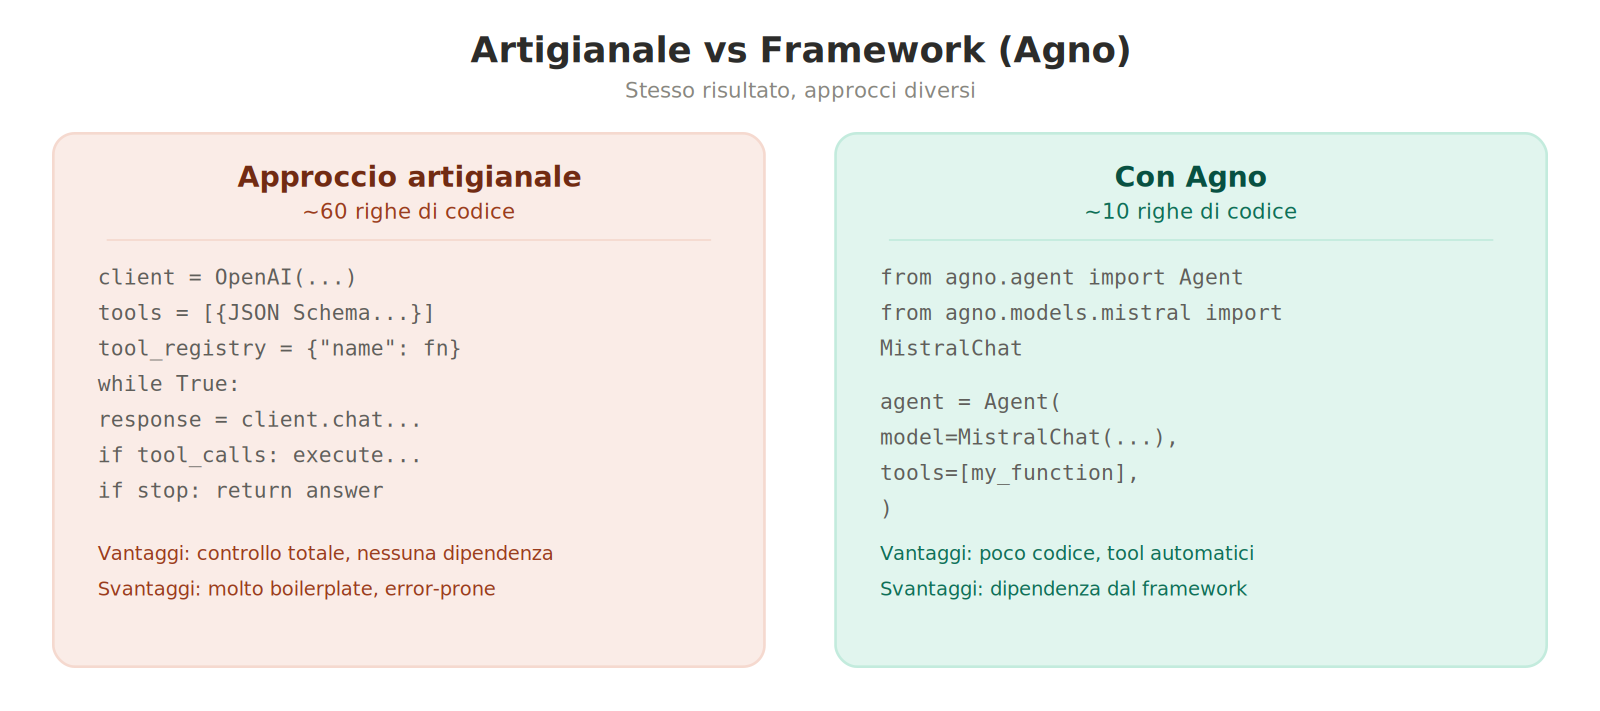

### Concetti chiave di Agno

| Concetto Agno | Cosa fa | Equivalente artigianale |
|---|---|---|
| `Agent` | L'agente con modello, tool, istruzioni | Il nostro `react_agent()` + setup |
| `tools=[fn]` | Tool come semplici funzioni Python | JSON Schema manuale + tool registry |
| `model=MistralChat(id="...")` | Provider e modello | `OpenAI(base_url=...)` + `MODEL` |
| `print_response()` | Esecuzione con output formattato | Il nostro loop + print |
| `debug_mode=True` | Log dettagliato | Il nostro logging manuale |
| `add_history_to_context=True` | Memoria multi-turno automatica | Gestione manuale della lista `messages` |

La differenza chiave: con Agno, **le funzioni Python diventano tool automaticamente** — dal type hint e dal docstring.


In [2]:
# === Installazione Agno con supporto Mistral e web search ===
!pip install -q agno[mistral,sqlite] ddgs


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.7/56.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.9/935.9 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-sdk 1.38.0 requires opentelemetry-api==1.38.0, but you have opentelemetry-api 1.39.1 which is incompatible.
opentelemetry-sdk 1.38.0 requires opentelemetry-semantic-conventions==0.59b0, but you have opentelemetry-semantic-conventions 0.60b1 which is incompati

In [3]:
# === Agente Agno minimale con Mistral ===

import os
from google.colab import userdata

# API key gratuita da https://console.mistral.ai
os.environ["MISTRAL_API_KEY"] = userdata.get("MISTRAL_API_KEY")

from agno.agent import Agent
from agno.models.mistral import MistralChat

# I tool sono semplici funzioni Python — Agno genera lo schema automaticamente!
def get_weather(city: str) -> str:
    """Ottieni il meteo attuale di una citta italiana. Restituisce temperatura e condizioni."""
    weather_data = {
        "Roma": "22C, soleggiato",
        "Milano": "17C, nuvoloso",
        "Napoli": "25C, soleggiato",
        "Torino": "15C, pioggia leggera",
    }
    return weather_data.get(city, f"{city}: dati non disponibili")

def calculate(expression: str) -> str:
    """Calcola un'espressione matematica. Supporta +, -, *, / e parentesi."""
    allowed = set("0123456789+-*/.(). ")
    if not all(c in allowed for c in expression):
        return "Errore: espressione non valida"
    try:
        return str(eval(expression))
    except Exception as e:
        return f"Errore: {e}"

# Creiamo l'agente — confronta con le ~60 righe dell'approccio artigianale!
agent = Agent(
    model=MistralChat(id="mistral-small-latest"),
    tools=[get_weather, calculate],
    instructions=[
        "Sei un assistente utile. Usa i tool a disposizione per rispondere.",
        "Puoi fare piu chiamate a tool in sequenza se necessario.",
    ],
    markdown=True,
)

print("Agente Agno + Mistral creato!")


Agente Agno + Mistral creato!


In [4]:
# === Demo: stesso task del notebook 7A, ma con Agno ===

agent.print_response(
    "Che tempo fa a Roma e Milano? Qual e' la media delle temperature?",
    stream=True
)


┏━ Message ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                                              ┃
┃ Che tempo fa a Roma e Milano? Qual e' la media delle temperature?            ┃
┃                                                                              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛
┏━ Tool Calls ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                                              ┃
┃ • get_weather(city=Roma)                                                     ┃
┃ • get_weather(city=Milano)                                                   ┃
┃ • calculate(expression=(22 + 17) / 2)                                        ┃
┃                                                                              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛
┏━ Response (2.2s) ━━━━━━━━━

Confronta con l'implementazione artigianale del notebook 7A:
- **Nessun JSON Schema** — Agno lo genera dal type hint + docstring
- **Nessun loop manuale** — Agno gestisce il ciclo ReAct internamente
- **Nessun tool registry** — basta passare le funzioni nella lista `tools`

> **Nota per il docente**: sotto il cofano, Agno fa esattamente ciò che abbiamo scritto a mano nel notebook 7A. Il valore del framework è astrazione, non magia.


### Agno con web search reale

`WebSearchTools` è il toolkit di Agno per la ricerca web — usa la libreria `ddgs` che supporta backend multipli (Google, Bing, DuckDuckGo, Brave, ecc.). Non richiede API key aggiuntive:


In [6]:
# === Agente con web search reale ===

from agno.agent import Agent
from agno.models.mistral import MistralChat
from agno.tools.websearch import WebSearchTools

ricercatore = Agent(
    model=MistralChat(id="mistral-small-latest"),
    tools=[WebSearchTools()],
    instructions=[
        "Sei un ricercatore. Cerca informazioni sul web e sintetizzale in modo chiaro.",
        "Cita sempre le fonti.",
    ],
    markdown=True,
)

ricercatore.print_response(
    "Cos'e' il Model Context Protocol (MCP) di Anthropic?",
    stream=True
)


┏━ Message ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                                              ┃
┃ Cos'e' il Model Context Protocol (MCP) di Anthropic?                         ┃
┃                                                                              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛
┏━ Tool Calls ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                                              ┃
┃ • web_search(query=Model Context Protocol (MCP) Anthropic definizione e      ┃
┃ caratteristiche)                                                             ┃
┃                                                                              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛
┏━ Response (5.1s) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                           

### Agno con conversazioni multi-turno

Con `add_history_to_context=True`, Agno mantiene automaticamente la cronologia:

In [10]:
# === Agente con memoria multi-turno ===

from agno.db.sqlite import SqliteDb

chat_agent = Agent(
    model=MistralChat(id="mistral-small-latest"),
    tools=[get_weather, calculate],
    instructions=["Sei un assistente utile con memoria delle conversazioni precedenti."],
    db=SqliteDb(db_file="tmp/agno_demo.db"),  # necessario per la cronologia
    add_history_to_context=True,
    num_history_runs=5,
    markdown=True,
)

# Turno 1
print("--- Turno 1 ---")
chat_agent.print_response("Che tempo fa a Roma?", stream=True)

# Turno 2: l'agente dovrebbe ricordare Roma
print("\n--- Turno 2 ---")
chat_agent.print_response("E a Milano? Confronta con la citta di prima.", stream=True)

# Turno 3: test di memoria
print("\n--- Turno 3 ---")
chat_agent.print_response("Qual era la citta piu calda tra quelle che abbiamo visto?", stream=True)


--- Turno 1 ---
┏━ Message ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                                              ┃
┃ Che tempo fa a Roma?                                                         ┃
┃                                                                              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛
┏━ Tool Calls ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                                              ┃
┃ • get_weather(city=Roma)                                                     ┃
┃                                                                              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛
┏━ Response (1.2s) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                                              ┃
┃ A Roma att

Osserva come l'agente ricorda le città precedenti **senza gestire manualmente la lista dei messaggi**.

> **Nota per il docente**: `num_history_runs=5` è context engineering! Agno applica automaticamente la strategia **Select** — include solo le ultime N interazioni per non esplodere il contesto.


---
## 2.3 — Riepilogo e mappa concettuale

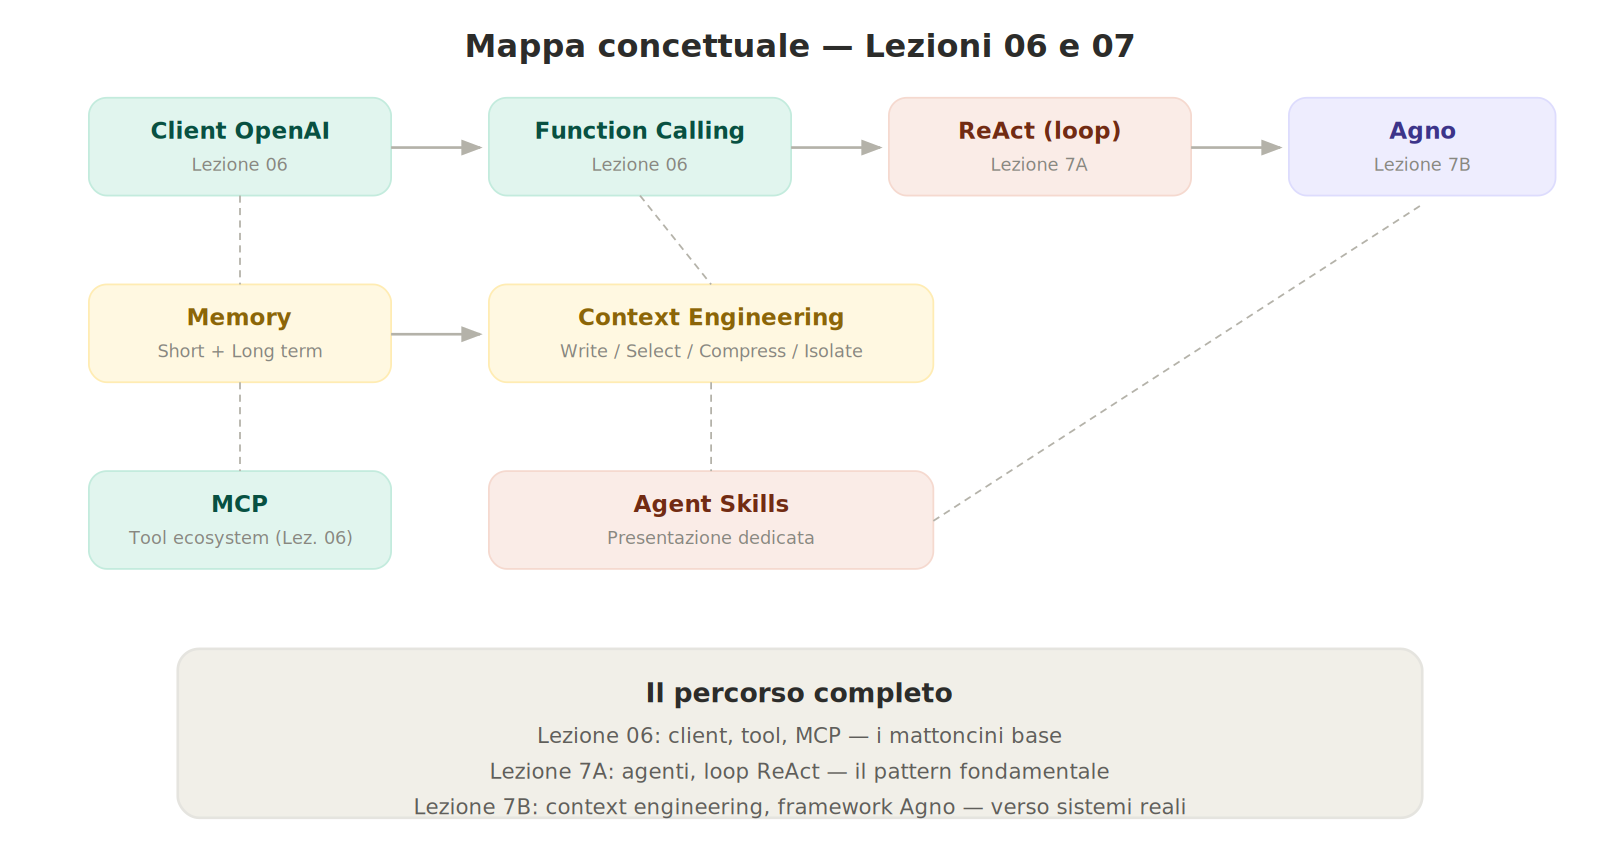

### Take-away

1. Il **Context Engineering** è l'evoluzione del prompt engineering — serve orchestrare 6 fonti di contesto
2. Le 4 strategie (**Write, Select, Compress, Isolate**) si applicano in combinazione — oggi ne abbiamo viste tre dal vivo (Compress, Select, Isolate)
3. I **framework** come Agno astraggono il boilerplate — ma capire cosa c'è sotto (notebook 7A) è fondamentale
4. Agno trasforma funzioni Python in tool automaticamente — da ~60 righe a ~10 righe
5. `add_history_to_context` e `num_history_runs` in Agno sono context engineering "gratis"

**Nei prossimi notebook** (7C-7F): esercitazioni per mettere in pratica tutto questo!

---

> **Nelle prossime lezioni**: le strategie Write e Select le vedremo in azione nella lezione 9 (RAG from Scratch) e nella lezione 10 (utilizzo avanzato degli agenti con Agno), dove affronteremo anche MCP lato client, Agent Skills, Team di agenti, e pattern avanzati come Reflection e Human-in-the-Loop.